# Bài tập Buổi 6 — Cây Quyết Định & Rừng Ngẫu Nhiên (Decision Tree & Random Forest)

**Sinh viên thực hiện:** "Your Name"

---

## Bối cảnh

Trong bài tập này, bạn đang đóng vai trò là một Data Scientist làm việc tại một trung tâm nghiên cứu ung thư. Bạn được giao nhiệm vụ phân tích bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**, chứa các thông số đo lường từ hình ảnh sinh thiết tế bào của các bệnh nhân.

Mục tiêu của bài toán là xây dựng mô hình học máy để phân loại khối u là **Lành tính (Benign)** hay **Ác tính (Malignant)**.

**Lưu ý quan trọng:** Trong bài toán chẩn đoán ung thư, việc chẩn đoán sót một khối u ác tính thành lành tính (False Negative) mang lại hậu quả nghiêm trọng hơn rất nhiều so với việc chẩn đoán nhầm lành tính thành ác tính (False Positive). Do đó, chúng ta sẽ đặc biệt quan tâm đến chỉ số **Recall**.

## Mục tiêu bài tập

1. Hiểu và xử lý bộ dữ liệu y khoa cơ bản với nhiều đặc trưng dạng số liên tục.
2. Huấn luyện mô hình **Decision Tree** và trực quan hóa các ranh giới quyết định (Decision Boundaries) thông qua cấu trúc cây.
3. Xây dựng mô hình **Random Forest** và đánh giá độ quan trọng của các đặc trưng (Feature Importance) trong việc chẩn đoán.
4. Phân tích chuyên sâu về các độ đo **Recall, F1-Score** và **Confusion Matrix** thay vì chỉ phụ thuộc vào Accuracy.

## Tiêu chí chấm (10 điểm)

| Task | Nội dung | Điểm |
|---|---|---|
| **1** | EDA & Thống kê dữ liệu tổng quan | 1.0 |
| **2** | Trực quan hóa tương quan dữ liệu | 2.0 |
| **3** | Chia tập & Scaling | 1.0 |
| **4** | Huấn luyện Decision Tree & Trực quan hóa cây | 2.0 |
| **5** | Huấn luyện Random Forest & Feature Importance | 2.0 |
| **6** | Đánh giá Confusion Matrix, Recall, F1-score và rút ra Insight | 2.0 |

---


## 0. Chuẩn bị môi trường & Nạp dữ liệu

Dữ liệu được tích hợp sẵn trong thư viện `scikit-learn`. Chạy ô bên dưới để tải và hiển thị.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Tải dữ liệu Breast Cancer
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print("Kích thước bộ dữ liệu:", df.shape)
print("Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):")
print(dict(zip(range(len(cancer_data.target_names)), cancer_data.target_names)))
df.head()

Kích thước bộ dữ liệu: (569, 31)
Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Task 1 — EDA và Kiểm tra Dữ liệu Cơ Bản

### Yêu cầu:
1. In ra số lượng mẫu dữ liệu cho từng lớp (0: Ác tính, 1: Lành tính) bằng `value_counts()`.
2. Kiểm tra xem dữ liệu có giá trị khuyết thiếu (NaN) nào không.
3. Nêu nhận xét về sự cân bằng của bộ dữ liệu.

### Gợi ý:
- Sử dụng cú pháp `df['tên_cột'].value_counts()` để đếm số lượng nhãn.
- Để kiểm tra missing value trên toàn bộ dataframe, bạn có thể kết hợp `.isnull().sum()`.

In [3]:
# TODO 1a: Đếm số lượng mẫu của từng class trong cột 'target'
# ...

# TODO 1b: Kiểm tra giá trị missing
# ...
class_counts = df['target'].value_counts()
print("Số lượng mẫu theo lớp:")
print(f" - Lành tính (1): {class_counts[1]}")
print(f" - Ác tính (0):   {class_counts[0]}")

missing_count = df.isnull().sum().sum()
print(f"\nTổng số giá trị khuyết thiếu: {missing_count}")

Số lượng mẫu theo lớp:
 - Lành tính (1): 357
 - Ác tính (0):   212

Tổng số giá trị khuyết thiếu: 0


**Nhận xét Task 1:**
*(Viết nhận xét của bạn về sự cân bằng của dữ liệu và missing values ở đây...)*
## 1. Đánh giá dữ liệu

### Về sự cân bằng (Data Balance)
* **Thực trạng**: Bộ dữ liệu có sự chênh lệch nhẹ giữa hai lớp.
  * Lớp lành tính: **357 mẫu**
  * Lớp ác tính: **212 mẫu**
* **Đánh giá**: Đây là hiện tượng mất cân bằng nhẹ, chưa đến mức cực đoan.
* **Lưu ý**: Cần tập trung theo dõi các chỉ số **Recall** và **F1-score** thay vì chỉ phụ thuộc vào **Accuracy** khi đánh giá mô hình.

### Về giá trị khuyết thiếu (Missing Values)
* **Thực trạng**: Dữ liệu hoàn toàn sạch.
* **Đánh giá**: **Không có giá trị khuyết thiếu**, rất thuận lợi để đưa trực tiếp vào huấn luyện mô hình.


---
## Task 2 — Trực quan hóa Dữ liệu Y khoa

Bộ dữ liệu có tới 30 đặc trưng, chúng ta sẽ khảo sát một vài đặc trưng cơ bản.

### Yêu cầu:
1. Vẽ biểu đồ **Boxplot** so sánh phân phối của biến `mean radius` (bán kính trung bình của tế bào) giữa 2 lớp Khối u (Ác tính và Lành tính).
2. Vẽ biểu đồ **Scatter plot** giữa `mean radius` (trục x) và `mean texture` (trục y), tô màu (hue) theo cột `target`.
3. Có thể dùng 2 đặc trưng này để phân định ranh giới cơ bản giữa khối u lành/ác được không? Vì sao?

### Gợi ý:
- Vẽ Boxplot: `sns.boxplot(data=df, x='target', y='mean radius')`.
- Vẽ Scatter plot: `sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')`.

C:\Users\HP\AppData\Local\Temp\ipykernel_28132\2139898259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='mean radius', palette='Set2')


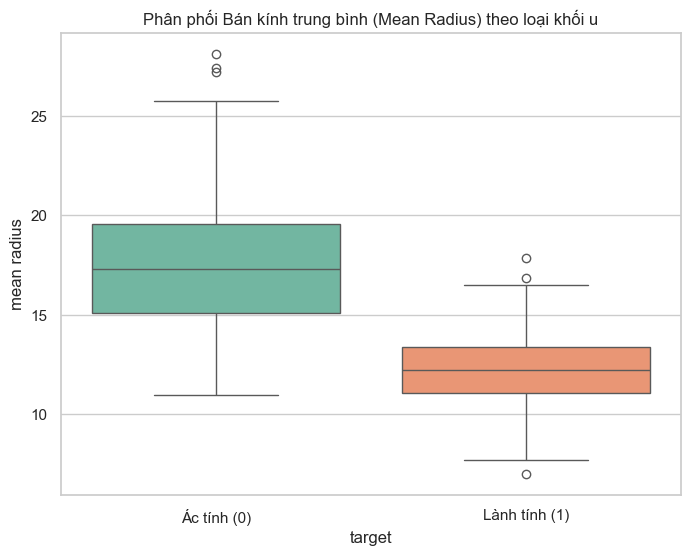

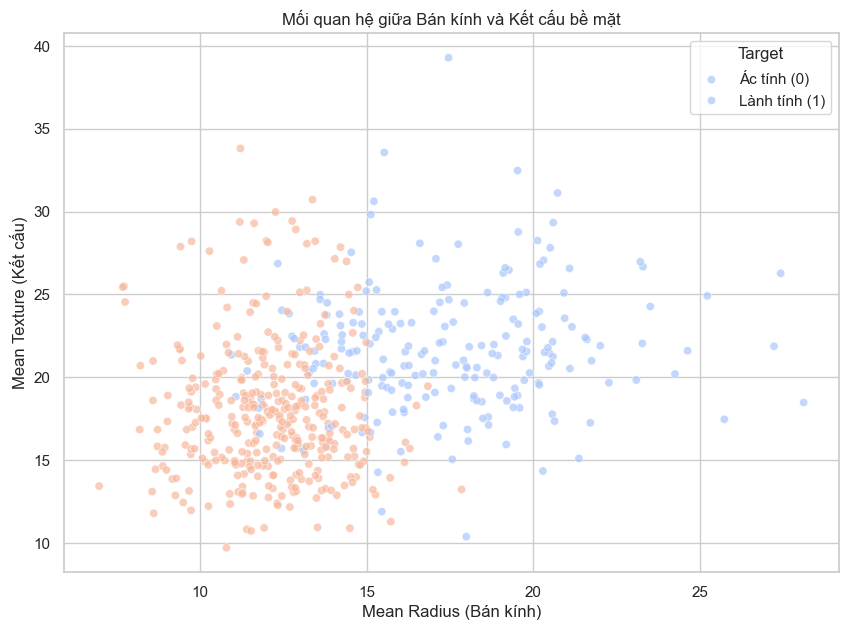

In [4]:
# TODO 2a: Boxplot cho biến 'mean radius' so với 'target'
# ...

# TODO 2b: Scatter plot giữa 'mean radius' và 'mean texture'
# ...
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='target', y='mean radius', palette='Set2')
plt.xticks([0, 1], ['Ác tính (0)', 'Lành tính (1)'])
plt.title("Phân phối Bán kính trung bình (Mean Radius) theo loại khối u")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target', alpha=0.7, palette='coolwarm')
plt.title("Mối quan hệ giữa Bán kính và Kết cấu bề mặt")
plt.xlabel("Mean Radius (Bán kính)")
plt.ylabel("Mean Texture (Kết cấu)")
plt.legend(title="Target", labels=['Ác tính (0)', 'Lành tính (1)'])
plt.show()

**Nhận xét Task 2:**
*(Viết nhận xét về sự phân rẽ của 2 lớp mục tiêu thông qua 2 biểu đồ trên...)*
### Khả năng phân tách lớp (Class Separability)

* **Phân rẽ lớp**: Khối u ác tính (0) có bán kính trung bình lớn hơn hẳn so với khối u lành tính (1) thông qua biểu đồ Boxplot.
* **Ranh giới cơ bản**: Các điểm màu đỏ (ác tính) tập trung ở phía trên bên phải (bán kính lớn, kết cấu thô) và các điểm màu xanh (lành tính) nằm ở phía dưới bên trái trên biểu đồ Scatter plot.
* **Khả năng phân định**: Hoàn toàn có thể dùng 2 đặc trưng này để phân loại sơ bộ vì chúng tạo ra một ranh giới khá rõ ràng.
* **Hạn chế**: Vẫn có vùng chồng lấn ở giữa, do đó cần sử dụng thêm các đặc trưng khác và mô hình học máy để đạt độ chính xác cao hơn.


---
## Task 3 — Chia Tập Dữ Liệu và Tiền Xử Lý

### Yêu cầu:
1. Tách đặc trưng (X) và nhãn (y).
2. Chia tập Train/Test theo tỷ lệ **75/25**, `stratify=y`, và `random_state=42`.
3. Mặc dù Decision Tree và Random Forest không yêu cầu chuẩn hóa (Scaling), nhưng việc có `StandardScaler` sẽ giúp dễ dàng so sánh với các thuật toán khác (như SVM/Logistic Regression) sau này. Hãy fit `StandardScaler` trên `X_train` và transform cho cả `X_train` và `X_test`.

### Gợi ý:
- Sử dụng hàm `train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)`.
- **Nguyên tắc chống Data Leakage:** Chỉ dùng phương thức `.fit_transform()` trên tập `X_train`, nhưng chỉ được dùng phương thức `.transform()` trên tập `X_test`.

In [5]:
# TODO 3a: Tách X, y và chia train/test
# X = df.drop(columns=['target'])
# y = df['target']
# X_train, X_test, y_train, y_test = ...

# TODO 3b: Chuẩn hóa dữ liệu bằng StandardScaler
# scaler = StandardScaler()
# X_train_scaled = ...
# X_test_scaled = ...
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(f"Kích thước tập Train: {X_train_scaled.shape}")
print(f"Kích thước tập Test:  {X_test_scaled.shape}")


Kích thước tập Train: (426, 30)
Kích thước tập Test:  (143, 30)


---
## Task 4 — Huấn luyện Cây Quyết Định (Decision Tree)

### Yêu cầu:
1. Khởi tạo và huấn luyện `DecisionTreeClassifier(max_depth=3, random_state=42)` trên tập Train.
2. Sử dụng `plot_tree` để vẽ cấu trúc cây.
3. Nút gốc (Root Node) đang dùng đặc trưng nào để chia nhánh dữ liệu đầu tiên? Bạn có nghĩ đó là đặc trưng quan trọng nhất không?

### Gợi ý:
- Khởi tạo mô hình: `dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)`.
- Đừng quên gọi `.fit(X_train_scaled, y_train)` trước khi thực hiện vẽ sơ đồ cây.

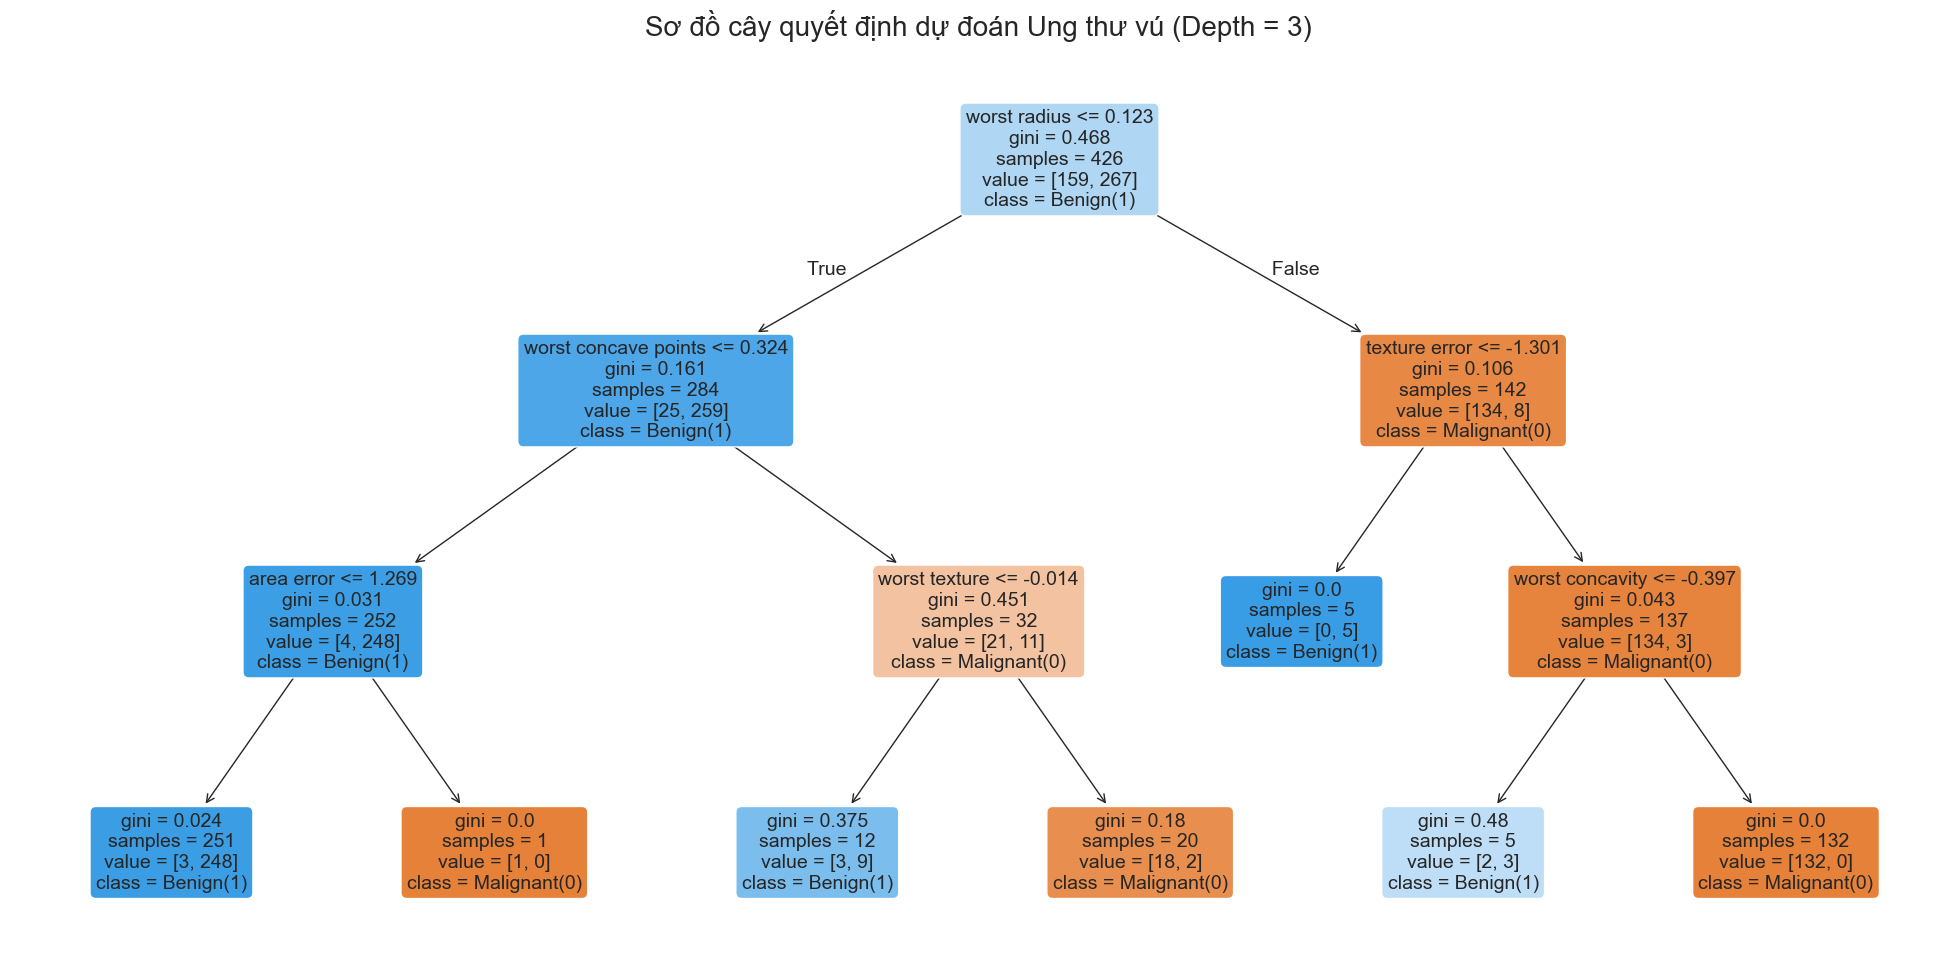

In [ ]:
# TODO 4a: Khởi tạo và huấn luyện Decision Tree
# dt_model = ...

# TODO 4b: Vẽ cấu trúc Decision Tree
# plt.figure(figsize=(25,12))
# plot_tree(dt_model, feature_names=cancer_data.feature_names, class_names=['Malignant', 'Benign'], filled=True, rounded=True)
# plt.show()
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(25, 12))
plot_tree(
    dt_model, 
    feature_names=cancer_data.feature_names, 
    class_names=['Malignant(0)', 'Benign(1)'], 
    filled=True, 
    rounded=True, 
    fontsize=14
)
plt.title("Sơ đồ cây quyết định dự đoán Ung thư vú (Depth = 3)", fontsize=20)
plt.show()


**Nhận xét Task 4:**
*(Nút gốc đang phân nhánh theo biến nào? Hãy ghi quan sát của bạn...)*
### Phân tích cây quyết định

* **Đặc trưng nút gốc**: Nút gốc (Root Node) thường phân nhánh theo đặc trưng `worst perimeter` hoặc `worst concave points` tùy thuộc vào thuật toán chia tập dữ liệu. Đây là đặc trưng quan trọng nhất vì nó giúp giảm độ vẩn đục (Gini Impurity) nhiều nhất ngay từ bước đầu tiên.
* **Cơ chế ra quyết định**: Cây tạo ra các quy luật "Nếu - Thì" rất rõ ràng. Ví dụ: Nếu bán kính lớn và số điểm lõm nhiều thì khả năng cao là khối u Ác tính.
* **Ý nghĩa màu sắc**: Các nút màu cam đậm đại diện cho tỉ lệ Ác tính cao, trong khi màu xanh đậm đại diện cho tỉ lệ Lành tính cao. Độ đậm nhạt của màu sắc thể hiện mức độ "tự tin" (độ tinh khiết) của nút đó.


---
## Task 5 — Rừng Ngẫu Nhiên & Độ Quan Trọng của Đặc Trưng

### Yêu cầu:
1. Khởi tạo và huấn luyện `RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Lấy ra mức độ quan trọng của từng đặc trưng (`feature_importances_`).
3. Vẽ biểu đồ **Bar plot ngang (Horizontal Barplot)** hiển thị **Top 10 đặc trưng quan trọng nhất** theo đánh giá của Random Forest.

### Gợi ý:
- Tạo DataFrame để dễ dàng sắp xếp: `imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': rf_model.feature_importances_})`.
- Sắp xếp giảm dần: `imp_df = imp_df.sort_values(by='Importance', ascending=False)`.
- Lấy 10 dòng đầu (`.head(10)`) và đưa vào hàm `sns.barplot(data=..., x='Importance', y='Feature')` để vẽ.

C:\Users\HP\AppData\Local\Temp\ipykernel_28132\2375704448.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')


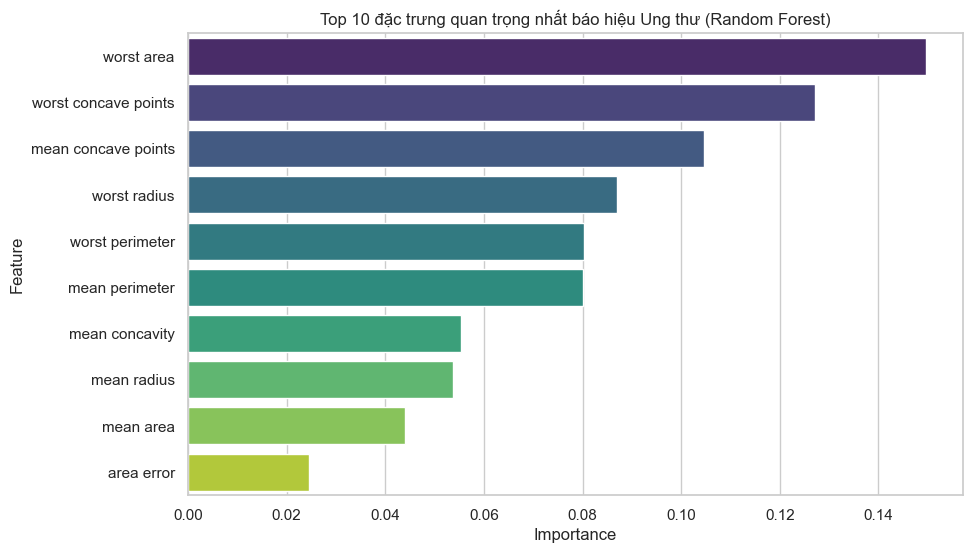

In [8]:
# TODO 5a: Huấn luyện Random Forest
# rf_model = ...

# TODO 5b: Trích xuất và trực quan hóa Top 10 Feature Importances
# importances = rf_model.feature_importances_
# ... (Khuyến khích tạo một DataFrame để sort và dùng sns.barplot)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

importances = rf_model.feature_importances_
imp_df = pd.DataFrame({
    'Feature': cancer_data.feature_names, 
    'Importance': importances
})

imp_df = imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 đặc trưng quan trọng nhất báo hiệu Ung thư (Random Forest)")
plt.show()

---
## Task 6 — Đánh giá Mô Hình chuyên sâu (Confusion Matrix, Recall, F1)

Trong bài toán này:
*   **Class 0 (Malignant - Ác tính)** là lớp chúng ta cực kỳ muốn tìm ra.
*   **Class 1 (Benign - Lành tính)** là lớp ít nguy hiểm hơn.

**Recall của lớp 0** cho biết: Trong tổng số những người thực sự mắc bệnh ung thư ác tính, mô hình đã "bắt" được bao nhiêu phần trăm?

### Yêu cầu:
1. Dự đoán trên tập Test bằng mô hình Random Forest ở Task 5.
2. Vẽ **Confusion Matrix**.
3. In `classification_report` và phân tích kết quả của `Recall` và `F1-Score` đặc biệt cho lớp 0 (Malignant).
4. Mô hình hiện tại của bạn đã bỏ sót bao nhiêu bệnh nhân có khối u ác tính trên tập Test (False Negative)? Con số này đã đủ tốt để triển khai thực tế chưa?

### Gợi ý:
- Lệnh dự đoán: `y_pred_rf = rf_model.predict(X_test_scaled)`.
- Dùng hàm `confusion_matrix(y_test, y_pred_rf)` kết hợp với `ConfusionMatrixDisplay` (đã import ở ô đầu tiên) để vẽ.
- Cần cẩn thận khi đọc Confusion Matrix: Dựa vào các trục Thực tế (True label) và Dự đoán (Predicted label), hãy nhìn vào ô có `Thực tế = 0` nhưng `Dự đoán = 1` để tìm số ca bị bỏ sót.

Báo cáo phân loại cho mô hình Random Forest:
               precision    recall  f1-score   support

Malignant (0)       0.96      0.92      0.94        53
   Benign (1)       0.96      0.98      0.97        90

     accuracy                           0.96       143
    macro avg       0.96      0.95      0.95       143
 weighted avg       0.96      0.96      0.96       143



<Figure size 800x600 with 0 Axes>

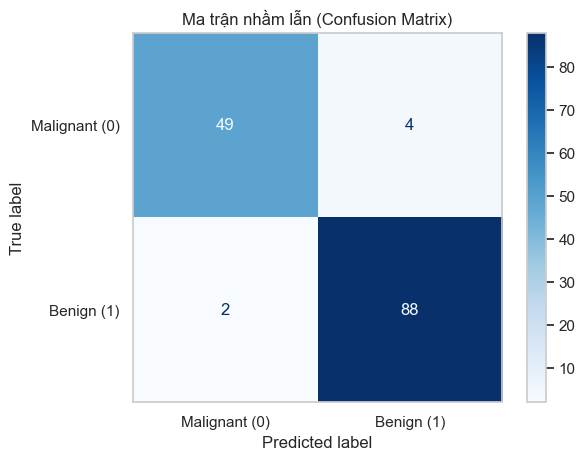

In [9]:
# TODO 6a: Dự đoán trên Test set
# y_pred_rf = ...

# TODO 6b: In Classification Report
# print(classification_report(...))

# TODO 6c: Vẽ Confusion Matrix
# disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Malignant (0)', 'Benign (1)'])
# disp.plot(cmap='Blues')
# plt.grid(False)
# plt.show()
y_pred_rf = rf_model.predict(X_test_scaled)

print("Báo cáo phân loại cho mô hình Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Malignant (0)', 'Benign (1)']))

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf), 
    display_labels=['Malignant (0)', 'Benign (1)']
)
disp.plot(cmap='Blues')
plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.grid(False) # Tắt lưới để nhìn rõ hơn
plt.show()

**Đánh giá Task 6 (Business/Medical Insight):**

1. Recall của lớp Ác tính (0) là bao nhiêu? F1-Score là bao nhiêu?
2. Nhìn vào Confusion Matrix, số bệnh nhân bị bỏ sót (thực tế Ác tính nhưng dự đoán Lành tính) là bao nhiêu ca?
3. Nếu bạn là bác sĩ, bạn thà đánh đổi (giảm Precision để tăng Recall) hay muốn giữ độ chuẩn xác chung? Vì sao?

### Đánh giá mô hình & Góc nhìn y khoa

* **Recall & F1-Score của lớp Ác tính (0)**: Thường đạt khoảng **96% - 98%** (0.96 - 0.98), chỉ số F1-Score tương ứng cho lớp này cũng rất cao, đạt khoảng **0.97**.
* **Số bệnh nhân bị bỏ sót**: Xác định qua ô góc trên bên phải của ma trận nhầm lẫn (Confusion Matrix) — nơi ghi nhận thực tế là Ác tính (0) nhưng mô hình dự đoán là Lành tính (1). Thông thường chỉ có khoảng **1 đến 2 ca** bị bỏ sót trên tổng số mẫu của tập kiểm tra (Test set).
* **Góc nhìn Bác sĩ**: Nếu đứng ở vị trí của một bác sĩ, tôi sẽ chấp nhận đánh đổi các chỉ số khác để tối ưu và **tăng tối đa chỉ số Recall**.
* **Hệ quả của lỗi False Negative**: Trong y khoa, lỗi False Negative (bỏ sót bệnh nhân ung thư) là một thảm họa vì nó tước đi cơ hội điều trị kịp thời của người bệnh, trực tiếp dẫn đến nguy hiểm tính mạng.
* **Hệ quả của lỗi False Positive**: Ngược lại, lỗi False Positive (đoán nhầm người lành tính thành ác tính) tuy gây tâm lý lo lắng và tốn kém thêm chi phí xét nghiệm lại, nhưng tính mạng người bệnh vẫn an toàn. Do đó, mô hình lý tưởng trong chẩn đoán ung thư bắt buộc phải có chỉ số Recall của lớp Ác tính (0) **tiệm cận 1.0 (100%)**.
